# Expression analysis SHMss events

In [1]:
# Load packages
options(warn = -1)
library("IRdisplay")
library(tidyverse)
library(Seurat)
library(ggh4x)
library(data.table)

── Attaching packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.4.0      ✔ purrr   1.0.1 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.3.0      ✔ stringr 1.5.0 
✔ readr   2.1.3      ✔ forcats 0.5.2 
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
Attaching SeuratObject


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose




In [2]:
suppressMessages(source("code/functions.R"))

## Load data

### Load input data (all sequences)

In [3]:
df_seq <- Sys.glob("input/output_shm_20220819/*/consensus/*/*.csv")  %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "cciccici", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>%
      filter(ref_vdj_coverage == "1.0")
  })

### Load list of cells with complete VDJ

In [4]:
df_complete_cells <- df_seq %>%  
                     mutate(experiment =str_extract(subject, "^.{3}")) %>% mutate(subject = str_extract(subject, "(?<=_)[^_]+(?=-)")) %>% select(experiment, subject, cell) %>% unique()

### Load all SHMss events detected (positive + false positive)

In [5]:
# load data
df <- Sys.glob("input/output_shm_20220819/shm_incl_po/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "ccicccilciicc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
  })

### Load df with filtered SHMss events (trully positive)

In [6]:
df_summary <- read.csv("output/df_summary_K45678_v5.csv")
str(df_summary)

'data.frame':	294 obs. of  9 variables:
 $ subject               : chr  "K4B_S8934-HC" "K4B_S8934-HC" "K4B_S8934-HC" "K4B_S8934-HC" ...
 $ cell                  : chr  "TGTCCCAGTTTGTTGG" "TGAGAGGCAGACTCGC" "AGATCTGAGACCGGAT" "AGGCCGTGTGCGCTTG" ...
 $ vgene_position_aligned: int  4 9 18 70 186 188 241 247 260 269 ...
 $ nucl_po               : chr  "G" "G" "G" "G" ...
 $ context_po            : chr  "AG.TG" "CA.CT" "GA.TC" "CA.CC" ...
 $ subregion             : chr  "FR1" "FR1" "FR1" "FR1" ...
 $ variation             : chr  "A-G" "A-G" "A-G" "A-G" ...
 $ umis                  : chr  "18-8" "34-69" "6-5" "5-5" ...
 $ productive            : logi  TRUE TRUE TRUE TRUE TRUE TRUE ...


### Load expression data (SCT transformation and merge)

**Apply sctransform normalization** I did this step and bellow also I will do the normalization all together (integration

Note that this single command replaces NormalizeData(), ScaleData(), and FindVariableFeatures().
Transformed data will be available in the SCT assay, which is set as the default after running sctransform
During normalization, we can also remove confounding sources of variation, for example, mitochondrial mapping percentage

In [7]:
# # read expression data (every experiment)
# K4B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/112_CellRanger_analysis/K4B_S8934_66747/outs/multi/count/raw_feature_bc_matrix")) %>%
#   CreateSeuratObject(project = "K4B", min.cells = 3, min.features = 200) %>% 
#                 SCTransform( return.only.var.genes = FALSE ,conserve.memory=TRUE)

# K5B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/112_CellRanger_analysis/K5B_S8934_1336560/outs/multi/count/raw_feature_bc_matrix")) %>%
#   CreateSeuratObject(project = "K5B", min.cells = 3, min.features = 200) %>% 
#                 SCTransform( return.only.var.genes = FALSE,conserve.memory=TRUE )

# # save individual objects
# saveRDS( K4B, "output/K4B_SCT.rds")
# saveRDS( K5B, "output/K5B_SCT.rds")

In [8]:
# K6B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/112_CellRanger_analysis/K6B_S13530/LN13530_GEX/outs/raw_feature_bc_matrix")) %>%
#   CreateSeuratObject(project = "K6B", min.cells = 3, min.features = 200) %>% 
#                 SCTransform( return.only.var.genes = FALSE ,conserve.memory=TRUE)

# saveRDS( K6B, "output/K6B_SCT.rds")

In [9]:
# K7B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/112_CellRanger_analysis/K7B_S10000_1095790/FL10000_count/outs/multi/count/raw_feature_bc_matrix")) %>%
#   CreateSeuratObject(project = "K7B", min.cells = 3, min.features = 200) %>% 
#                 SCTransform( return.only.var.genes = FALSE,conserve.memory=TRUE )

# saveRDS( K7B, "output/K7B_SCT.rds")

In [10]:
# K8B <- Read10X(data.dir = paste0("~/repositories/FL_10X_2/112_CellRanger_analysis/K8B_S13553_1311480/FL13553_count/outs/multi/count/raw_feature_bc_matrix")) %>%
#   CreateSeuratObject(project = "K8B", min.cells = 3, min.features = 200) %>% 
#                 SCTransform( return.only.var.genes = FALSE,conserve.memory=TRUE)

# saveRDS( K8B, "output/K8B_SCT.rds")

In [11]:
# # # compbined the 3 experiments
# FL_combined <- merge(K4B, y = c(K5B, K6B,K7B, K8B), add.cell.ids = c("K4B","K5B", "K6B","K7B", "K8B"), project = "FL")
# FL_combined

In [12]:
# # # save merge object
# saveRDS(FL_combined, "output/K45678_merge.rds")

### Integrate 5 dataset and remove batch effect

**Tips for integrating large datasets**
https://satijalab.org/seurat/articles/integration_large_datasets.html

- For very large datasets, the standard integration workflow can sometimes be prohibitively computationally expensive. In this workflow, we employ two options that can improve efficiency and runtimes:

1. Reciprocal PCA (RPCA)
2. Reference-based integration (I did not do this one)

- This alternative workflow consists of the following steps:

1. Create a list of Seurat objects to integrate
2. Perform normalization, feature selection, and scaling separately for each dataset
3. Run PCA on each object in the list
4. Integrate datasets, and proceed with joint analysis

In [13]:
K4B <- readRDS("output/K4B.rds")
K5B <- readRDS("output/K5B.rds")
K6B <- readRDS("output/K6B.rds")
K7B <- readRDS("output/K7B.rds")
K8B <- readRDS("output/K8B.rds")

In [14]:
# # merge in a list
# l <-
#   list(K4B, K5B, K6B, K7B, K8B)

**first perform standard normalization and variable feature selection**

In [15]:
# l <- lapply(X = l, FUN = function(x) {
#     x <- NormalizeData(x, verbose = FALSE)
#     x <- FindVariableFeatures(x, verbose = FALSE)
# })

**Next, select features for downstream integration, and run PCA on each object in the list, which is required for running the alternative reciprocal PCA workflow**

In [16]:
# features <-   SelectIntegrationFeatures( object.list = l, nfeatures = 3500 ) %>% 
#     as.data.frame() %>% 
#     dplyr::rename( geneName = "." ) %>% 
#     filter( !geneName %like% "^RPL",
#             !geneName %like% "^RPS",
#             !geneName %like% "^MT-" ) %>% 
#     slice_head( n = 3000 ) %>% 
#   pull( geneName )
# l <- lapply(X = l, FUN = function(x) {
#     x <- ScaleData(x, features = features, verbose = FALSE)
#     x <- RunPCA(x, features = features, verbose = FALSE)
# })

**The main efficiency improvements are gained in FindIntegrationAnchors(). First, we use reciprocal PCA (RPCA) instead of CCA, to identify an effective space in which to find anchors.
When determining anchors between any two datasets using reciprocal PCA, we project each dataset into the others PCA space and constrain the anchors by the same mutual neighborhood requirement. All downstream integration steps remain the same and we are able to ‘correct’ (or harmonize) the datasets.**

In [17]:
# anchors <- FindIntegrationAnchors(object.list = l, reduction = "rpca",
#     dims = 1:50)

**Integrate data and save data**

In [18]:
# FL.integrated <- IntegrateData(anchorset = anchors, dims = 1:50)

In [19]:
# # save integrated object
# saveRDS(FL.integrated, "output/K45678_integrated.rds")

### List of genes

In [20]:
filename <- "input/names_genes_dna_repair.csv"
genes_names <- read.csv(filename)

In [21]:
# number of genes analysed
length(genes_names$gene)

[1] 66

## **Analysis non normal data**

In [22]:
dataset <- K4B

# filter only the GEX for the list of genes
dd1 <- dataset@assays$RNA@counts %>% #FL_combined@assays$RNA@counts
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% genes_names$gene) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell") %>%
  mutate(experiment= "K4B")

head(dd1)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,XRCC1,LIG1,PNKP,POLD1,PCNA,CHAF1B,APEX2,ERCC6L,RPA4,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGAGACGAA-1,0,0,1,0,2,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K4B
2,AAACCTGAGCCACGTC-1,0,0,0,0,1,0,0,0,0,⋯,0,0,0,1,0,0,0,0,0,K4B
3,AAACCTGAGCTAGTTC-1,0,0,0,0,3,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K4B
4,AAACCTGAGTAACCCT-1,0,0,0,0,2,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K4B
5,AAACCTGAGTGATCGG-1,0,0,1,0,5,0,0,0,0,⋯,0,0,0,0,1,0,0,0,0,K4B
6,AAACCTGCAAGTCTAC-1,0,0,0,0,2,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K4B


In [23]:
dataset <- K5B

# filter only the GEX for the list of genes
dd2 <- dataset@assays$RNA@counts %>% #FL_combined@assays$RNA@counts
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% genes_names$gene) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell") %>%
  mutate(experiment= "K5B")

head(dd2)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,XRCC1,LIG1,PNKP,POLD1,PCNA,CHAF1B,APEX2,ERCC6L,RPA4,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGCCATCGC-1,1,0,1,0,1,0,0,0,0,⋯,0,0,1,0,0,0,0,0,0,K5B
2,AAACCTGAGCGTTCCG-1,0,0,1,0,4,0,1,0,0,⋯,1,0,0,0,0,0,0,0,0,K5B
3,AAACCTGAGGAGTTTA-1,0,0,0,0,3,0,1,1,0,⋯,0,0,0,0,0,0,0,0,0,K5B
4,AAACCTGAGTTTAGGA-1,1,0,1,0,11,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K5B
5,AAACCTGCACAGTCGC-1,0,0,1,0,3,0,0,0,0,⋯,0,0,1,0,0,0,0,0,0,K5B
6,AAACCTGCACATTTCT-1,1,0,1,0,31,0,0,1,0,⋯,2,2,4,2,0,0,0,0,0,K5B


In [24]:
dataset <- K6B

# filter only the GEX for the list of genes
dd3 <- dataset@assays$RNA@counts %>% #FL_combined@assays$RNA@counts
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% genes_names$gene) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell") %>%
  mutate(experiment= "K6B")

head(dd3)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,XRCC1,LIG1,PNKP,POLD1,PCNA,CHAF1B,APEX2,ERCC6L,RPA4,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGACCGGAT-1,0,0,0,0,8,0,0,0,0,⋯,1,0,1,0,0,0,0,0,0,K6B
2,AAACCTGAGCTAGTGG-1,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K6B
3,AAACCTGAGGATGCGT-1,0,0,0,0,6,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,K6B
4,AAACCTGAGGGTTTCT-1,0,0,0,0,3,0,0,0,0,⋯,0,0,0,0,0,0,1,0,0,K6B
5,AAACCTGCAAGGCTCC-1,0,0,1,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,K6B
6,AAACCTGCAAGTAGTA-1,0,0,0,0,3,0,0,0,0,⋯,0,1,0,0,0,0,0,0,0,K6B


In [25]:
dataset <- K7B

# filter only the GEX for the list of genes
dd4 <- dataset@assays$RNA@counts %>% #FL_combined@assays$RNA@counts
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% genes_names$gene) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell") %>%
  mutate(experiment= "K7B")

head(dd4)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,XRCC1,LIG1,PNKP,POLD1,PCNA,CHAF1B,APEX2,ERCC6L,RPA4,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGAAACCGC-1,0,0,1,0,3,0,0,0,0,⋯,0,0,1,0,0,0,0,0,0,K7B
2,AAACCTGAGAATCTCC-1,0,0,0,0,0,0,0,0,0,⋯,0,0,1,0,0,0,0,0,0,K7B
3,AAACCTGAGACAAAGG-1,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K7B
4,AAACCTGAGACGACGT-1,0,0,1,0,3,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K7B
5,AAACCTGAGACTTTCG-1,2,0,0,0,4,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K7B
6,AAACCTGAGAGCTTCT-1,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K7B


In [26]:
dataset <- K8B

# filter only the GEX for the list of genes
dd5 <- dataset@assays$RNA@counts %>% #FL_combined@assays$RNA@counts
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% genes_names$gene) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell") %>%
  mutate(experiment= "K8B")

head(dd5)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,XRCC1,LIG1,PNKP,POLD1,PCNA,CHAF1B,APEX2,ERCC6L,RPA4,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGAAAGTGG-1,0,0,0,0,3,0,0,0,0,⋯,0,0,0,0,0,0,1,0,0,K8B
2,AAACCTGAGAACAACT-1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K8B
3,AAACCTGAGATCCCGC-1,0,0,0,0,2,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K8B
4,AAACCTGAGCGCTCCA-1,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K8B
5,AAACCTGAGCTAAGAT-1,0,0,0,0,1,0,0,0,0,⋯,0,0,1,0,0,0,0,0,0,K8B
6,AAACCTGAGTGAACGC-1,3,0,0,0,6,0,0,0,0,⋯,1,0,1,1,0,0,0,0,0,K8B


In [27]:
# clean df and include experiment column
pd <- bind_rows(dd1,dd2,dd3,dd4,dd5) %>%
  mutate(cell = gsub(".{2}$", "", cell)) 
head(pd)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,XRCC1,LIG1,PNKP,POLD1,PCNA,CHAF1B,APEX2,ERCC6L,RPA4,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGAGACGAA,0,0,1,0,2,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K4B
2,AAACCTGAGCCACGTC,0,0,0,0,1,0,0,0,0,⋯,0,0,0,1,0,0,0,0,0,K4B
3,AAACCTGAGCTAGTTC,0,0,0,0,3,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K4B
4,AAACCTGAGTAACCCT,0,0,0,0,2,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K4B
5,AAACCTGAGTGATCGG,0,0,1,0,5,0,0,0,0,⋯,0,0,0,0,1,0,0,0,0,K4B
6,AAACCTGCAAGTCTAC,0,0,0,0,2,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,K4B


In [28]:
table(pd$experiment)


  K4B   K5B   K6B   K7B   K8B 
 9425 11829 12199 16312 16493 

### Transform to a categorical variable**

In [29]:
# tranform values to categorical
pd_cat <- pd %>%
  mutate_if(is.numeric, ~ ifelse(. == 0, "No", "Yes"))
head(pd_cat)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,XRCC1,LIG1,PNKP,POLD1,PCNA,CHAF1B,APEX2,ERCC6L,RPA4,experiment
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AAACCTGAGAGACGAA,No,No,Yes,No,Yes,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,K4B
2,AAACCTGAGCCACGTC,No,No,No,No,Yes,No,No,No,No,⋯,No,No,No,Yes,No,No,No,No,No,K4B
3,AAACCTGAGCTAGTTC,No,No,No,No,Yes,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,K4B
4,AAACCTGAGTAACCCT,No,No,No,No,Yes,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,K4B
5,AAACCTGAGTGATCGG,No,No,Yes,No,Yes,No,No,No,No,⋯,No,No,No,No,Yes,No,No,No,No,K4B
6,AAACCTGCAAGTCTAC,No,No,No,No,Yes,No,No,No,No,⋯,No,No,No,No,No,No,No,No,No,K4B


**Obtain categorical expression**

In [30]:
# merge SHMss and expression data
cell_list <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 3),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pd_cat, by = c("cell", "experiment")) %>% #  right_join(pd_cat, by = c("cell"="cell", "experiment"= "sample")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

In [31]:
# barcodes of cell with scSHM to filter the df qith all the events
cells_SHM <- cell_list %>% filter(group == "SHMss_observed") %>% pull(cell)

We removed cell without a complete VDJ of the all cells aand also the cell that could be false positive

In [32]:
# remove incomplete cells and possible false positives

#This ones are ~21000 cells
false_positives <- df %>% # df with all events
  filter(!cell %in% cells_SHM) %>% #revove of the list of false positives the real positive cells
  mutate(experiment = str_sub(subject, 1, 3), group = "SHMss_not_observed") %>%
  select(experiment, cell, group) %>%
  distinct()

cell_list <- cell_list %>%
  right_join(df_complete_cells) %>% #df with all cell with complete VDJ
  anti_join(false_positives) %>%
  filter(!is.na(group))

Joining, by = c("experiment", "cell")
Joining, by = c("experiment", "cell", "group")


In [33]:
write.csv(false_positives %>% select(experiment,cell), "output/false_positives_cell_scSHM_K45678B.csv",row.names=FALSE)

In [34]:
# summarize data (df for scSHM notebook)
shm_perc_sub <-  cell_list %>%
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>%
  select(-experiment, -cell) %>%
  group_by(subject, gene, group, expression) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange(subject, gene, group)

In [35]:
cell_list_cat <- cell_list

In [36]:
write.csv(shm_perc_sub, "output/expresion_data_perc_sub_K45678_cat.csv", row.names=FALSE)

In [37]:
# summarize data
shm_perc <- cell_list %>%
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>%
  select(-experiment, -cell) %>%
  group_by(gene, group, expression) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange( gene, group)

### Obtain Range of expression (categorical not binary)

In [38]:
# merge SHMss and expression data
cell_list <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 3),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pd, by = c("cell", "experiment")) %>% #here the right join is with pd (no categorical)
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

In [39]:
# # remove incomplete cells and possible false positives
# false_positives <- df %>%
#    filter(!cell %in% cells_SHM) %>% #revove of the list of false positives the real positive cells
#   mutate(experiment = str_sub(subject, 1, 3), group = "SHMss_not_observed") %>%
#   select(experiment, cell, group) %>%
#   distinct()

# cell_list <- cell_list %>%
#   right_join(df_complete_cells) %>%
#   anti_join(false_positives) %>%
#   filter(!is.na(group))

# remove incomplete cells and possible false positives
false_positives <- df %>%
   filter(!cell %in% cells_SHM) %>% #revove of the list of false positives the real positive cells
  mutate(experiment = str_sub(subject, 1, 3), group = "SHMss_not_observed") %>%
  select(experiment, cell, group) %>%
  distinct()

cell_list <- cell_list %>%
  right_join(df_complete_cells) %>%
  anti_join(false_positives) %>%
  filter(!is.na(group))

Joining, by = c("experiment", "cell")
Joining, by = c("experiment", "cell", "group")


In [40]:
# summarize data and transform numeric values to a range
shm_perc_sub <-  cell_list %>% select(-subject) %>%
  gather( -experiment, -cell, -group, key = "gene", value = "expression") %>% #-subject,
  mutate(expression_cat = case_when(
     (expression > 3) & (expression < 11)  ~ "4-10",
     (expression >10)  ~ ">10",
     TRUE ~ as.character(expression))) %>%
  select(-experiment, -cell,-expression) %>%
  group_by( gene, group, expression_cat) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange( gene, group)

In [41]:
write.csv(shm_perc_sub, "output/expresion_data_perc_sub_K45678_no_cat.csv", row.names=FALSE)

### Plotting: DNA repair genes expression analysis

In [42]:
#define gene order for plotting
gene_order <- shm_perc_sub %>% filter(group == "SHMss_not_observed", expression_cat == "0") %>% arrange(-perc) %>% pull(gene) %>% unique()
gene_order

[1] "RPA4"   "ERCC6L" "POLE2"  "NEIL2"  "POLQ"   "FAM72A" "EXO1"   "APLF"  
 [9] "CHAF1B" "NEIL3"  "POLE"   "LIG3"   "MSH5"   "RFC5"   "POLD1"  "MLH3"  
[17] "PARP2"  "NTHL1"  "POLB"   "POLD3"  "CHAF1A" "SMUG1"  "UNG"    "MSH3"  
[25] "AICDA"  "RFC4"   "PARP4"  "LIG1"   "MUTYH"  "MSH2"   "MLH1"   "FEN1"  
[33] "RFC3"   "PCNA"   "APEX2"  "POLL"   "PMS2"   "APTX"   "PMS1"   "PARP3" 
[41] "XRCC1"  "RFC2"   "RECQL"  "RPA1"   "POLD2"  "POLE3"  "OGG1"   "MSH6"  
[49] "TDG"    "POLE4"  "NUDT1"  "PNKP"   "RPA2"   "RPA3"   "RFC1"   "ADAR"  
[57] "APEX1"  "HMGB2"  "NEIL1"  "MPG"    "MBD4"   "POLD4"  "PARP1"  "HMGB1"

In [43]:
# change name of pathway
pathway.labs <- c('','BER','BER/MMR','MMR')
names(pathway.labs) <- c('SHM','BER','BER/MMR','MMR')

# change name of group
group.labs <- c("SHMss observed","SHMss not observed")
names(group.labs) <- c("SHMss_observed","SHMss_not_observed")

In [44]:
shm_perc_pub <- shm_perc_sub %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                 filter(!gene %in% c("ADAR")) %>% 
                 mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
                 mutate(expression_cat = factor(expression_cat, levels = c('0','1','2','3','4-10','>10'))) %>%
                 mutate(diagnosis="FL") 
#                 mutate(expression = case_when(
#     (gene == "AICDA") & (expression == "No") ~ "F",
#     (gene == "AICDA") & (expression == "Yes") ~ "T",
#     TRUE ~ expression))

In [45]:
write.csv(shm_perc_sub, "output/shm_perc_sub_nonorm_K45678.csv", row.names=FALSE)

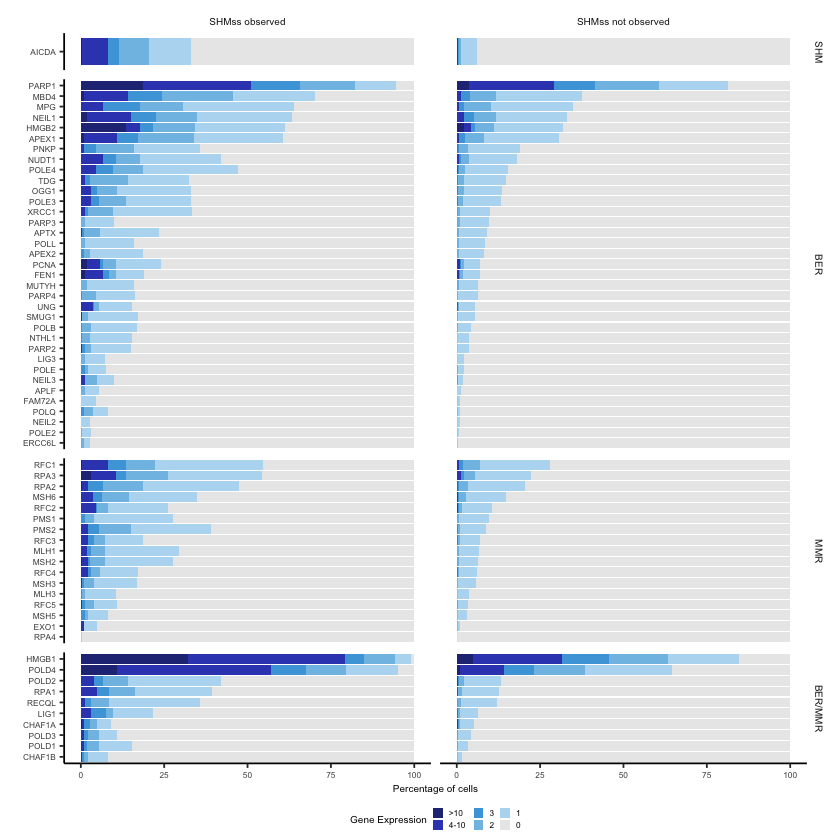

In [46]:
expre_summary <- ggplot(shm_perc_pub, aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free", labeller = labeller(group = group.labs)) +  #labeller = labeller(pathway = pathway.labs
  force_panelsizes(rows = c(0.1, 1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/FL/DNA_repair_expresion_no_norm", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

### Integrate CLL data

In [47]:
shm_perc_CLL <- read.csv("output/shm_perc_sub_CLL_to_merge_no_norm.csv") 

### add combinations of columns (complete (function))

In [48]:
shm_perc_pub_int <- shm_perc_pub %>%
  bind_rows(shm_perc_CLL) %>%
  ungroup() %>%
    complete(
    diagnosis, group, nesting(gene, pathway), 
    fill = list(expression_cat = "0", count = 0, perc  = 100)
  ) %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                      mutate(group = case_when(
                    (group == "SHMss_observed") & (diagnosis == "FL")  ~ "FL scSHM \n observed",
                    (group == "SHMss_not_observed") & (diagnosis == "FL")  ~ "FL scSHM \n not observed",
                    (group == "SHMss_observed") & (diagnosis == "CLL")  ~ "CLL scSHM \n observed",
                    (group == "SHMss_not_observed") & (diagnosis == "CLL")  ~ "CLL scSHM \n not observed"
                    )) %>%
                    mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
                    mutate(expression_cat = factor(expression_cat, levels = c('0','1','2','3','4-10','>10'))) %>%
                    mutate(group = factor(group, levels = c("FL scSHM \n observed","FL scSHM \n not observed", "CLL scSHM \n not observed","CLL scSHM \n observed")))

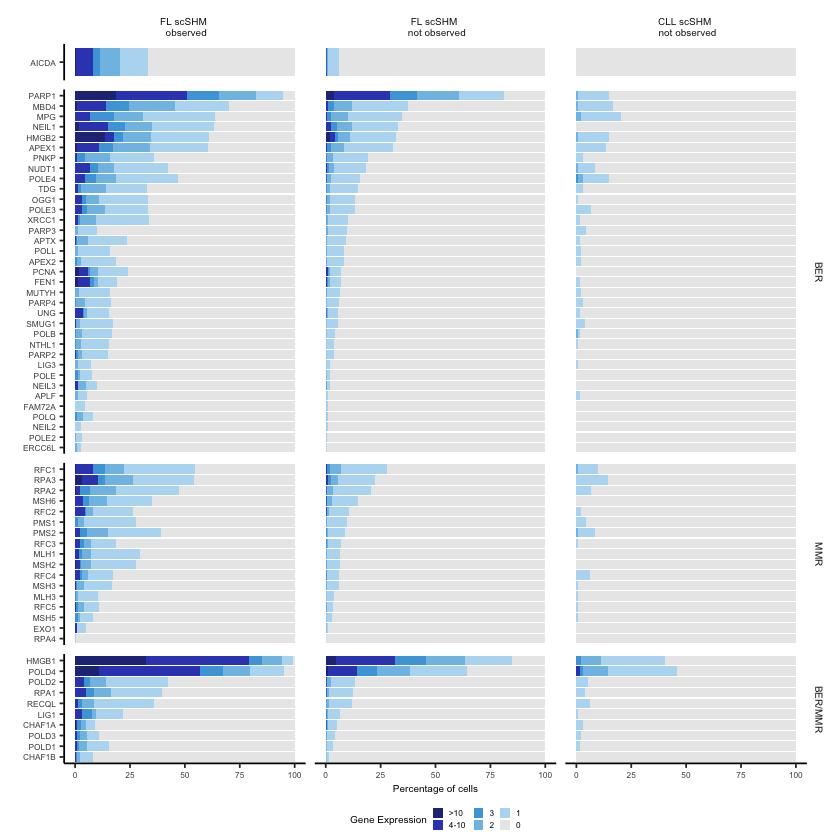

In [49]:
expre_summary <- ggplot(shm_perc_pub_int %>% filter(group != "CLL scSHM \n observed"), aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
#  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free",labeller = labeller(pathway = pathway.labs )) +  # labeller = labeller(group = group.labs)
  force_panelsizes(rows = c(0.1, 1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/DNA_repair_expresion_no_norm", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 800)
expre_summary

## ADAR gene (RNA editing) expression analysis
**Fisher test**

In [50]:
shm_summary_adar <- shm_perc %>%
  filter(gene == "ADAR") %>%
  group_by(group, expression) %>%
  summarise(counts = sum(count)) %>%
  spread(expression, counts) %>%
  column_to_rownames(var = "group")
shm_summary_adar

`summarise()` has grouped output by 'group'. You can override using the `.groups` argument.


,No,Yes
,<int>,<int>
SHMss_observed,119,102
SHMss_not_observed,4212,1690


The Fisher’s exact test is used when there is at least one cell in the contingency table of the expected frequencies below 5. To retrieve the expected frequencies, use the chisq.test() function together with $expected:

In [51]:
chisq.test(shm_summary_adar)$expected

,No,Yes
SHMss_observed,156.3206,64.67941
SHMss_not_observed,4174.6794,1727.32059


In [52]:
test <- fisher.test(shm_summary_adar)
test


	Fisher's Exact Test for Count Data

data:  shm_summary_adar
p-value = 6.597e-08
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 0.3541185 0.6198875
sample estimates:
odds ratio 
 0.4681626 


In [53]:
shm_perc %>%
  filter(gene == "ADAR") %>%
  group_by(group, expression) # %>% summarise(count = sum(counts)) %>% mutate(Percentage= count * 100 / sum(count))

gene,group,expression,count,perc,pathway
<chr>,<fct>,<chr>,<int>,<dbl>,<chr>
ADAR,SHMss_observed,No,119,53.84615,RNSA_editing
ADAR,SHMss_observed,Yes,102,46.15385,RNSA_editing
ADAR,SHMss_not_observed,No,4212,71.36564,RNSA_editing
ADAR,SHMss_not_observed,Yes,1690,28.63436,RNSA_editing


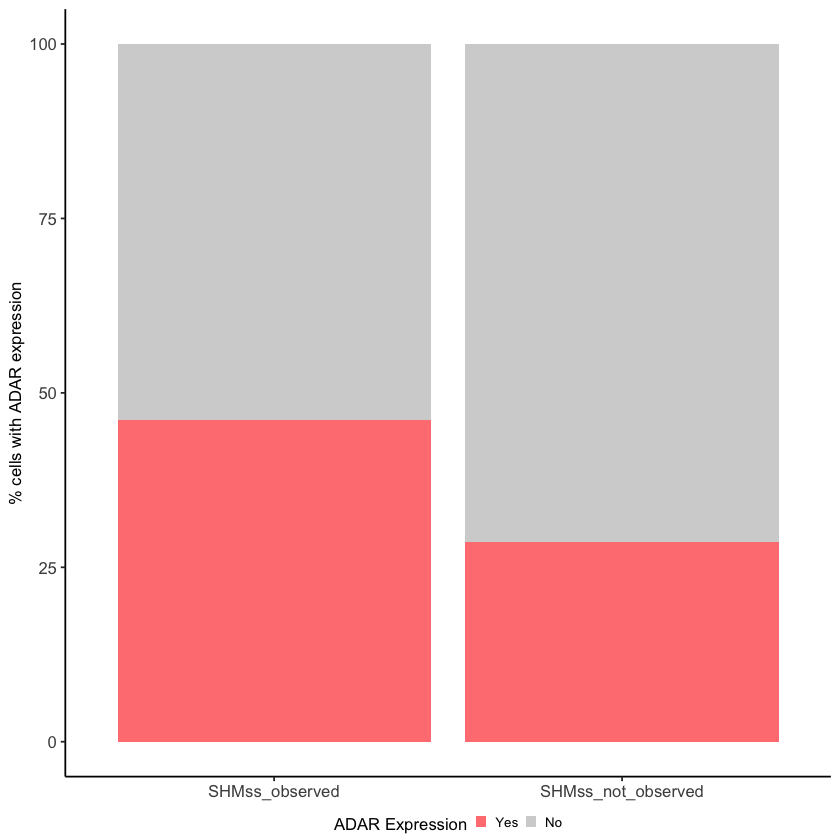

In [54]:
expre_summary <- ggplot(shm_perc %>% filter(gene == "ADAR") %>% group_by(group, expression), aes(x = group, y = perc, fill = expression)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = c("#d3d3d3", "#ff8181"), name = "ADAR Expression", guide = guide_legend(reverse = TRUE)) +
  labs(x = "", y = "% cells with ADAR expression") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.5, unit = "cm"),
    axis.text = element_text(size = 10, angle = 0),
    axis.title = element_text(size = 10),
    legend.title = element_text(size = 10), legend.text = element_text(size = 8), legend.key.size = unit(0.5, "line")
  )


fig_save(expre_summary, filename = "figs/FL/ADAR_expression_summary", formats = c("pdf", "png"), width = 10, height = 15, units = "cm", dpi = 320)
expre_summary

## TEST AID and ADAR

In [55]:
head(cell_list)

,experiment,cell,group,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,⋯,XRCC1,LIG1,PNKP,POLD1,PCNA,CHAF1B,APEX2,ERCC6L,RPA4,subject
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,K4B,TGTCCCAGTTTGTTGG,SHMss_observed,1,0,1,0,6,0,0,⋯,0,0,0,0,0,0,0,0,0,S8934
2,K4B,TGAGAGGCAGACTCGC,SHMss_observed,0,0,1,0,7,0,1,⋯,0,0,1,0,0,0,0,0,0,S8934
3,K4B,AGATCTGAGACCGGAT,SHMss_observed,1,1,2,0,4,0,0,⋯,0,0,0,0,0,0,0,0,0,S8934
4,K4B,AGGCCGTGTGCGCTTG,SHMss_observed,1,0,0,1,3,0,0,⋯,0,0,0,0,0,0,0,0,0,S8934
5,K4B,CTTTGCGTCAAGGTAA,SHMss_observed,0,0,1,0,11,0,1,⋯,0,3,2,1,2,0,1,0,0,S8934
6,K4B,GGACGTCTCGACCAGC,SHMss_observed,0,0,1,0,14,0,1,⋯,1,3,2,2,4,3,0,0,0,S8934


In [56]:
shm_summary_adar <- cell_list_cat %>%
   select(experiment, cell, group, AICDA, ADAR) #%>%
#   group_by(group, expression) %>%
#   summarise(counts = sum(count)) %>%
#   spread(expression, counts) %>%
#   column_to_rownames(var = "group")
head(shm_summary_adar)

,experiment,cell,group,AICDA,ADAR
,<chr>,<chr>,<chr>,<chr>,<chr>
1,K4B,TGTCCCAGTTTGTTGG,SHMss_observed,No,Yes
2,K4B,TGAGAGGCAGACTCGC,SHMss_observed,No,Yes
3,K4B,AGATCTGAGACCGGAT,SHMss_observed,Yes,Yes
4,K4B,AGGCCGTGTGCGCTTG,SHMss_observed,No,No
5,K4B,CTTTGCGTCAAGGTAA,SHMss_observed,No,Yes
6,K4B,GGACGTCTCGACCAGC,SHMss_observed,No,Yes


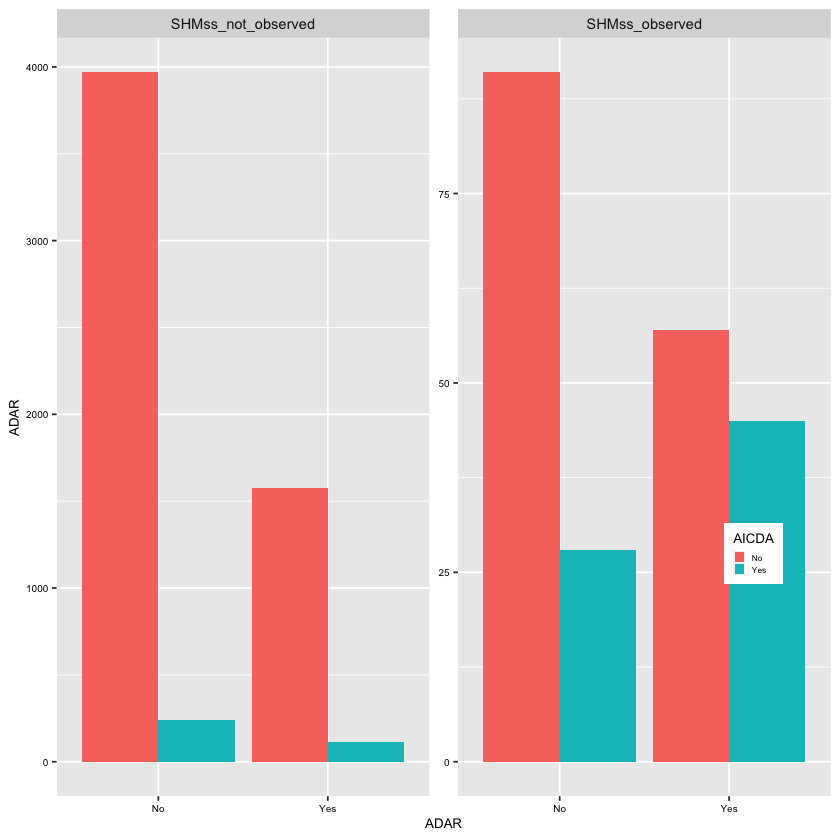

In [57]:
# Basic scatter plot
sx <- ggplot(shm_summary_adar %>% group_by(group) %>% count(AICDA,ADAR), aes(x=ADAR, y=n, fill=AICDA)) + 
  geom_bar(stat='identity',  position = position_dodge(preserve = 'single')) + #stat = "identity"
    theme(axis.text = element_text(size =6 , angle = 0, color="black"),
    axis.title = element_text(size = 8), axis.text.x = element_text(size = 6),
    legend.position=c(0.9, 0.32),
    legend.title = element_text(size = 8), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
     )  +
labs(y = "ADAR", x = "ADAR") +
   facet_wrap(.~group, scales="free_y")

sx

#fig_save(sx, filename = "figs/scatterplot_subclonal", formats = c("pdf", "png"), width = 7, height = 7, units = "cm", dpi = 800)

## **Analysis with normalize data**

- 'FL.integrated@assays$RNA@data' : NormalizeData divides each feature in a cell with the total UMI counts for that cell, multiples the number by 10000, and then natural log + 1 transforms the counts, so you don't expect any negative values. 
- ScaleData then centers and scales those counts.

In [58]:
FL.merge <- readRDS("output/K45678_merge.rds")

In [59]:
dataset <-FL.merge

# filter only the GEX for the list of genes
dda <- dataset@assays$SCT@data %>%
  as.data.frame() %>%
  rownames_to_column(var = "gene") %>%
  filter(gene %in% genes_names$gene) %>%
  column_to_rownames(var = "gene") %>%
  t() %>%
  as.data.frame() %>%
  rownames_to_column(var = "cell")

head(dda)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,CHAF1A,XRCC1,LIG1,PNKP,POLD1,PCNA,CHAF1B,APEX2,ERCC6L,RPA4
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,K4B_AAACCTGAGAGACGAA-1,0,0,0.6931472,0,1.098612,0,0,0,0,⋯,0,0,0,0,0.000000,0.0000000,0,0,0,0
2,K4B_AAACCTGAGCCACGTC-1,0,0,0.0000000,0,1.386294,0,0,0,0,⋯,0,0,0,0,1.098612,0.0000000,0,0,0,0
3,K4B_AAACCTGAGCTAGTTC-1,0,0,0.0000000,0,2.302585,0,0,0,0,⋯,0,0,0,0,0.000000,0.0000000,0,0,0,0
4,K4B_AAACCTGAGTAACCCT-1,0,0,0.0000000,0,1.098612,0,0,0,0,⋯,0,0,0,0,0.000000,0.0000000,0,0,0,0
5,K4B_AAACCTGAGTGATCGG-1,0,0,0.6931472,0,1.609438,0,0,0,0,⋯,0,0,0,0,0.000000,0.6931472,0,0,0,0
6,K4B_AAACCTGCAAGTCTAC-1,0,0,0.0000000,0,1.098612,0,0,0,0,⋯,0,0,0,0,0.000000,0.0000000,0,0,0,0


In [60]:
# clean df and include experiment column
pd <- dda %>%
  mutate(experiment = str_sub(cell, 1, 3)) %>% 
  mutate(cell = gsub("^.{4}|.{2}$", "", cell)) 
head(pd)

,cell,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,MSH6,APLF,⋯,XRCC1,LIG1,PNKP,POLD1,PCNA,CHAF1B,APEX2,ERCC6L,RPA4,experiment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,AAACCTGAGAGACGAA,0,0,0.6931472,0,1.098612,0,0,0,0,⋯,0,0,0,0.000000,0.0000000,0,0,0,0,K4B
2,AAACCTGAGCCACGTC,0,0,0.0000000,0,1.386294,0,0,0,0,⋯,0,0,0,1.098612,0.0000000,0,0,0,0,K4B
3,AAACCTGAGCTAGTTC,0,0,0.0000000,0,2.302585,0,0,0,0,⋯,0,0,0,0.000000,0.0000000,0,0,0,0,K4B
4,AAACCTGAGTAACCCT,0,0,0.0000000,0,1.098612,0,0,0,0,⋯,0,0,0,0.000000,0.0000000,0,0,0,0,K4B
5,AAACCTGAGTGATCGG,0,0,0.6931472,0,1.609438,0,0,0,0,⋯,0,0,0,0.000000,0.6931472,0,0,0,0,K4B
6,AAACCTGCAAGTCTAC,0,0,0.0000000,0,1.098612,0,0,0,0,⋯,0,0,0,0.000000,0.0000000,0,0,0,0,K4B


In [61]:
table(pd$experiment)


  K4B   K5B   K6B   K7B   K8B 
 9425 11829 12199 16312 16493 

In [62]:
# merge SHMss and expression data
cell_list <- df_summary %>%
  mutate(
    experiment = str_sub(subject, 1, 3),
    group = "SHMss_observed"
  ) %>%
  select(experiment, cell, group) %>%
  distinct() %>%
  right_join(pd, by = c("cell", "experiment")) %>%
  mutate(group = ifelse(is.na(group), "SHMss_not_observed", "SHMss_observed"))

In [87]:
read.csv("output/trully_negative_cells.csv")

source,cell
<chr>,<chr>
K4B,AAACCTGTCACGAAGG
K4B,AAACGGGAGTGGCACA
K4B,AAACGGGGTCTAGCGC
K4B,AAAGCAAGTACTTAGC
K4B,AAAGTAGCATCGGGTC
K4B,AAAGTAGGTCGGCTCA
K4B,AAAGTAGTCTTCGAGA
K4B,AAATGCCCATCCTAGA
K4B,AACACGTAGGTGACCA


In [63]:
# # remove incomplete cells and possible false positives
# false_positives <- df %>%
#   filter(!cell %in% cells_SHM) %>% #revove of the list of false positives the real positive cells
#   mutate(experiment = str_sub(subject, 1, 3), group = "SHMss_not_observed") %>%
#   select(experiment, cell, group) %>%
#   distinct()

# cell_list <- cell_list %>%
#   right_join(df_complete_cells) %>%
#   anti_join(false_positives)# remove incomplete cells and possible false positives

# remove incomplete cells and possible false positives
trully_negatives <- read.csv("output/trully_negative_cells.csv") %>%
  mutate(group = "SHMss_not_observed")

cell_list <- cell_list %>%
  right_join(df_complete_cells) %>%
  anti_join(false_positives)# remove incomplete cells and possible false positives

Joining, by = c("experiment", "cell")
Joining, by = c("experiment", "cell", "group")


In [88]:
head(cell_list)

,experiment,cell,group,RPA2,MUTYH,ADAR,FAM72A,PARP1,EXO1,MSH2,⋯,XRCC1,LIG1,PNKP,POLD1,PCNA,CHAF1B,APEX2,ERCC6L,RPA4,subject
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,K4B,TGTCCCAGTTTGTTGG,SHMss_observed,0.6931472,0.0000000,0.000000,0.0000000,1.386294,0,0.0000000,⋯,0,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0,0,0,S8934
2,K4B,TGAGAGGCAGACTCGC,SHMss_observed,0.0000000,0.0000000,0.000000,0.0000000,1.386294,0,0.6931472,⋯,0,0.0000000,0.6931472,0.0000000,0.0000000,0.0000000,0,0,0,S8934
3,K4B,AGATCTGAGACCGGAT,SHMss_observed,0.6931472,0.6931472,1.098612,0.0000000,1.386294,0,0.0000000,⋯,0,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0,0,0,S8934
4,K4B,AGGCCGTGTGCGCTTG,SHMss_observed,0.6931472,0.0000000,0.000000,0.6931472,1.098612,0,0.0000000,⋯,0,0.0000000,0.0000000,0.0000000,0.0000000,0.0000000,0,0,0,S8934
5,K4B,CTTTGCGTCAAGGTAA,SHMss_observed,0.0000000,0.0000000,0.000000,0.0000000,1.098612,0,0.0000000,⋯,0,0.6931472,0.6931472,0.0000000,0.6931472,0.0000000,0,0,0,S8934
6,K4B,GGACGTCTCGACCAGC,SHMss_observed,0.0000000,0.0000000,0.000000,0.0000000,1.609438,0,0.0000000,⋯,0,0.6931472,0.6931472,0.6931472,1.0986123,0.6931472,0,0,0,S8934


In [65]:
# summarize data
shm_perc_sub <-  cell_list %>% 
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>%
  mutate(expression_cat = case_when(
     (expression > 0) & (expression < 1)  ~ ">0<1",
     (expression >= 1) & (expression <= 2)  ~ "1-2",
     (expression >2)  ~ ">2",
     TRUE ~ as.character(expression))) %>%
  select(-experiment, -cell,-expression) %>%
  group_by( gene, group, expression_cat) %>%
  summarise(count = n(), .groups="drop_last") %>%
  mutate(perc = count / sum(count) * 100) %>%
  left_join(genes_names, by = c("gene")) %>%
  mutate(group = factor(group, levels = c("SHMss_observed", "SHMss_not_observed"))) %>%
  arrange( gene, group) %>% filter(!is.na(group))

In [66]:
head(shm_perc_sub)

gene,group,expression_cat,count,perc,pathway
<chr>,<fct>,<chr>,<int>,<dbl>,<chr>
ADAR,SHMss_observed,>0<1,35,15.837104,RNSA_editing
ADAR,SHMss_observed,0,181,81.900452,RNSA_editing
ADAR,SHMss_observed,1-2,5,2.262443,RNSA_editing
ADAR,SHMss_not_observed,>0<1,1102,18.671637,RNSA_editing
ADAR,SHMss_not_observed,0,4376,74.144358,RNSA_editing
ADAR,SHMss_not_observed,1-2,424,7.184005,RNSA_editing


### TEST

In [67]:
shm_perc_sub0 <-  cell_list %>% 
  gather(-subject, -experiment, -cell, -group, key = "gene", value = "expression") %>% filter(!is.na(expression) & expression != 0)

In [68]:
head(shm_perc_sub0)

,experiment,cell,group,subject,gene,expression
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
1,K4B,TGTCCCAGTTTGTTGG,SHMss_observed,S8934,RPA2,0.6931472
2,K4B,AGATCTGAGACCGGAT,SHMss_observed,S8934,RPA2,0.6931472
3,K4B,AGGCCGTGTGCGCTTG,SHMss_observed,S8934,RPA2,0.6931472
4,K6B,GTAGGCCTCTTGTTTG,SHMss_observed,S13530,RPA2,0.6931472
5,K6B,CTTCTCTAGCGCCTTG,SHMss_observed,S13530,RPA2,0.6931472
6,K6B,ACTGTCCCATCTGGTA,SHMss_observed,S13530,RPA2,0.6931472


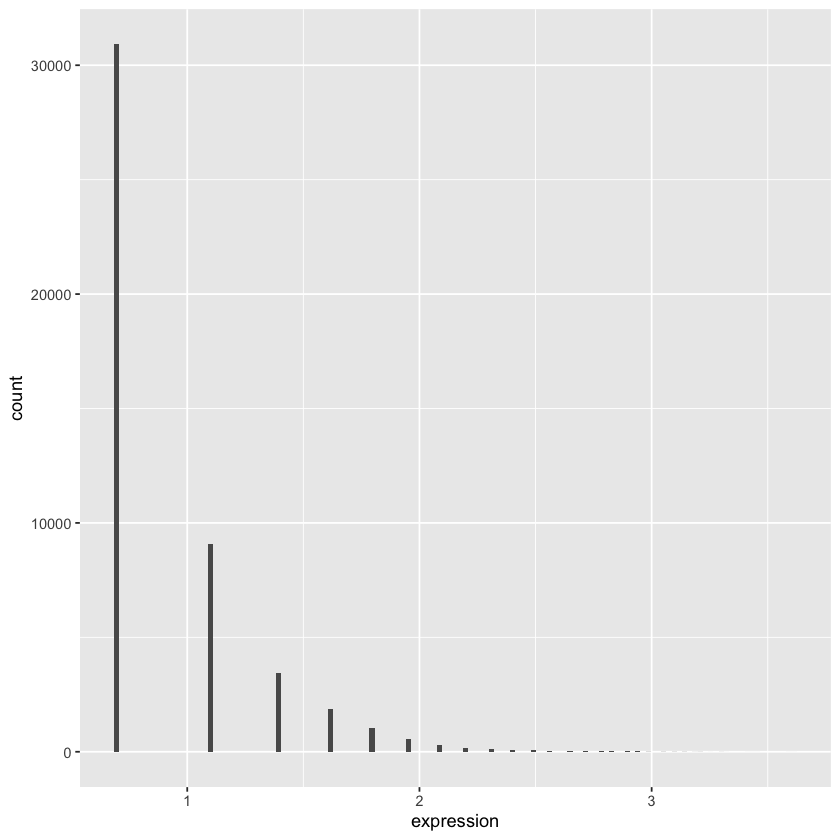

In [69]:
ggplot(shm_perc_sub0, aes(expression)) +
  geom_histogram(bins = nclass.FD(shm_perc_sub0$expression))

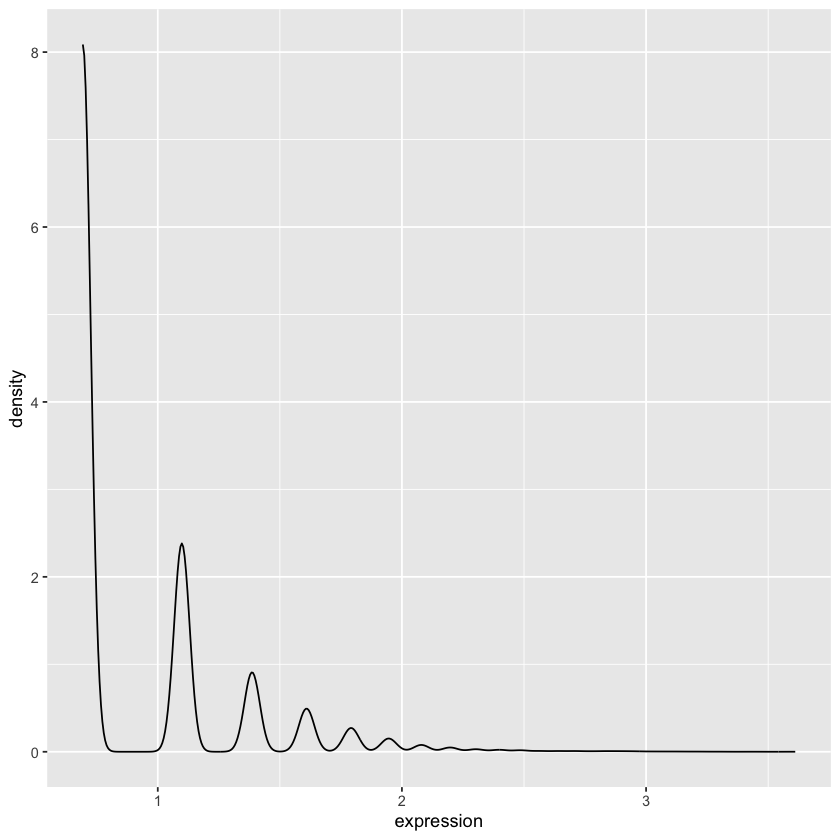

In [70]:
ggplot(shm_perc_sub0, aes(expression)) +
  geom_density() 

In [71]:
table(shm_perc_sub0$expression)


0.693147180559945  1.09861228866811  1.38629436111989   1.6094379124341 
            30906              9099              3462              1881 
 1.79175946922805  1.94591014905531  2.07944154167984  2.19722457733622 
             1037               578               297               186 
 2.30258509299405  2.39789527279837    2.484906649788  2.56494935746154 
              110                84                63                31 
 2.63905732961526  2.70805020110221  2.77258872223978  2.83321334405622 
               28                27                17                22 
 2.89037175789616  2.94443897916644  2.99573227355399  3.04452243772342 
               19                16                 8                 7 
 3.09104245335832  3.13549421592915  3.17805383034795   3.2188758248682 
                6                 6                 3                 5 
 3.25809653802148  3.29583686600433   3.3322045101752  3.40119738166216 
                1                 3               

In [72]:
write.csv(shm_perc_sub, "output/shm_perc_sub_norm_K45678.csv", row.names=FALSE)

### DNA repair genes expression analysis

In [73]:
#define gene order for plotting
gene_order <- shm_perc_sub %>% filter(group == "SHMss_not_observed", expression_cat == "0") %>% arrange(-perc) %>% pull(gene) %>% unique()
gene_order

[1] "RPA4"   "ERCC6L" "POLE2"  "POLQ"   "EXO1"   "NEIL2"  "APLF"   "FAM72A"
 [9] "CHAF1B" "NEIL3"  "POLE"   "LIG3"   "MSH5"   "RFC5"   "POLD1"  "NTHL1" 
[17] "PARP2"  "POLB"   "POLD3"  "MLH3"   "CHAF1A" "SMUG1"  "UNG"    "MSH3"  
[25] "RFC4"   "MLH1"   "MUTYH"  "LIG1"   "AICDA"  "MSH2"   "PARP4"  "RFC3"  
[33] "FEN1"   "PCNA"   "PMS2"   "APEX2"  "POLL"   "APTX"   "PMS1"   "XRCC1" 
[41] "PARP3"  "RFC2"   "RPA1"   "RECQL"  "POLD2"  "OGG1"   "POLE3"  "MSH6"  
[49] "POLE4"  "TDG"    "NUDT1"  "PNKP"   "RPA2"   "RPA3"   "RFC1"   "ADAR"  
[57] "APEX1"  "HMGB2"  "NEIL1"  "MPG"    "MBD4"   "POLD4"  "PARP1"  "HMGB1"

In [74]:
# change name of pathway
pathway.labs <- c('','BER','BER/MMR','MMR')
names(pathway.labs) <- c('SHM','BER','BER/MMR','MMR')

# change name of group
group.labs <- c("SHMss observed","SHMss not observed")
names(group.labs) <- c("SHMss_observed","SHMss_not_observed")

In [75]:
shm_perc_pub <- shm_perc_sub %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                 filter(!gene %in% c("ADAR")) %>% 
                 mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
                 mutate(expression_cat = factor(expression_cat, levels = c('0','>0<1','1-2','>2'))) %>%
                 mutate(diagnosis="FL") 
#                 mutate(expression = case_when(
#     (gene == "AICDA") & (expression == "No") ~ "F",
#     (gene == "AICDA") & (expression == "Yes") ~ "T",
#     TRUE ~ expression))

In [76]:
write.csv(shm_perc_pub, "output/shm_perc_sub_k45678.csv",row.names = FALSE) 

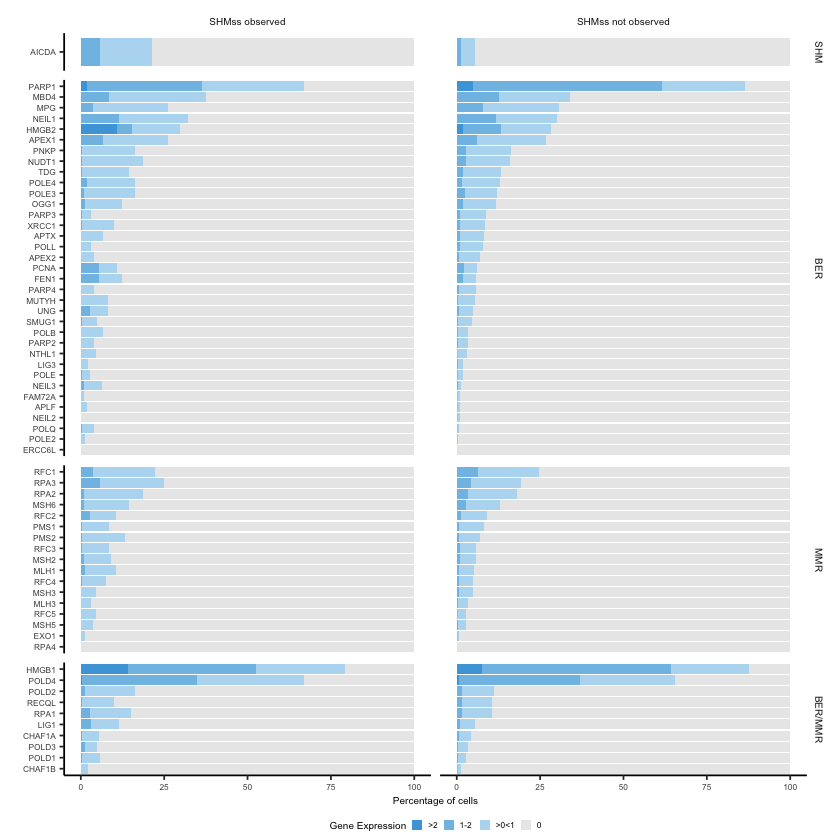

In [77]:
expre_summary <- ggplot(shm_perc_pub, aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free", labeller = labeller(group = group.labs)) +  #labeller = labeller(pathway = pathway.labs
  force_panelsizes(rows = c(0.1, 1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/FL/DNA_repair_expresion_norm", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

### Integrate CLL data

In [78]:
shm_perc_pub <- read.csv("output/shm_perc_sub_k45678.csv")  

In [79]:
shm_perc_CLL <- read.csv("output/shm_perc_sub_CLL_norm_v1.csv") 

In [80]:
head(shm_perc_CLL)

,gene,group,expression_cat,count,perc,pathway,diagnosis
,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>
1,APEX1,SHMss_not_observed,>0<1,18,13.533835,BER,CLL
2,APEX1,SHMss_not_observed,0,115,86.466165,BER,CLL
3,APEX2,SHMss_not_observed,>0<1,3,2.255639,BER,CLL
4,APEX2,SHMss_not_observed,0,130,97.744361,BER,CLL
5,APLF,SHMss_not_observed,>0<1,2,1.503759,BER,CLL
6,APLF,SHMss_not_observed,0,131,98.496241,BER,CLL


In [81]:
#Convert that column to a factor
shm_perc_pub$group <- as.character(shm_perc_pub$group) 

**add combinations of columns (complete (function))**

In [82]:
head(shm_perc_pub)

,gene,group,expression_cat,count,perc,pathway,diagnosis
,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>
1,AICDA,SHMss_observed,>0<1,34,15.384615,SHM,FL
2,AICDA,SHMss_observed,0,174,78.733032,SHM,FL
3,AICDA,SHMss_observed,1-2,13,5.882353,SHM,FL
4,AICDA,SHMss_not_observed,>0<1,252,4.269739,SHM,FL
5,AICDA,SHMss_not_observed,0,5573,94.425618,SHM,FL
6,AICDA,SHMss_not_observed,1-2,77,1.304642,SHM,FL


In [83]:
shm_perc_pub_int <- shm_perc_pub %>%
  bind_rows(shm_perc_CLL) %>%
    complete(
    diagnosis, group, nesting(gene, pathway), 
    fill = list(expression_cat = "0", count = 0, perc  = 100)
  ) %>% 
                 mutate(gene = factor(gene, levels = gene_order))  %>% 
                      mutate(group = case_when(
                    (group == "SHMss_observed") & (diagnosis == "FL")  ~ "FL scSHM \n observed",
                    (group == "SHMss_not_observed") & (diagnosis == "FL")  ~ "FL scSHM \n not observed",
                    (group == "SHMss_observed") & (diagnosis == "CLL")  ~ "CLL scSHM \n observed",
                    (group == "SHMss_not_observed") & (diagnosis == "CLL")  ~ "CLL scSHM \n not observed"
                    )) %>%
                    mutate(pathway = factor(pathway, levels = c('SHM','BER','MMR','BER/MMR'))) %>% 
                    mutate(expression_cat = factor(expression_cat, levels = c('0','>0<1','1-2','>2'))) %>%
                    mutate(group = factor(group, levels = c("FL scSHM \n observed","FL scSHM \n not observed", "CLL scSHM \n not observed","CLL scSHM \n observed")))

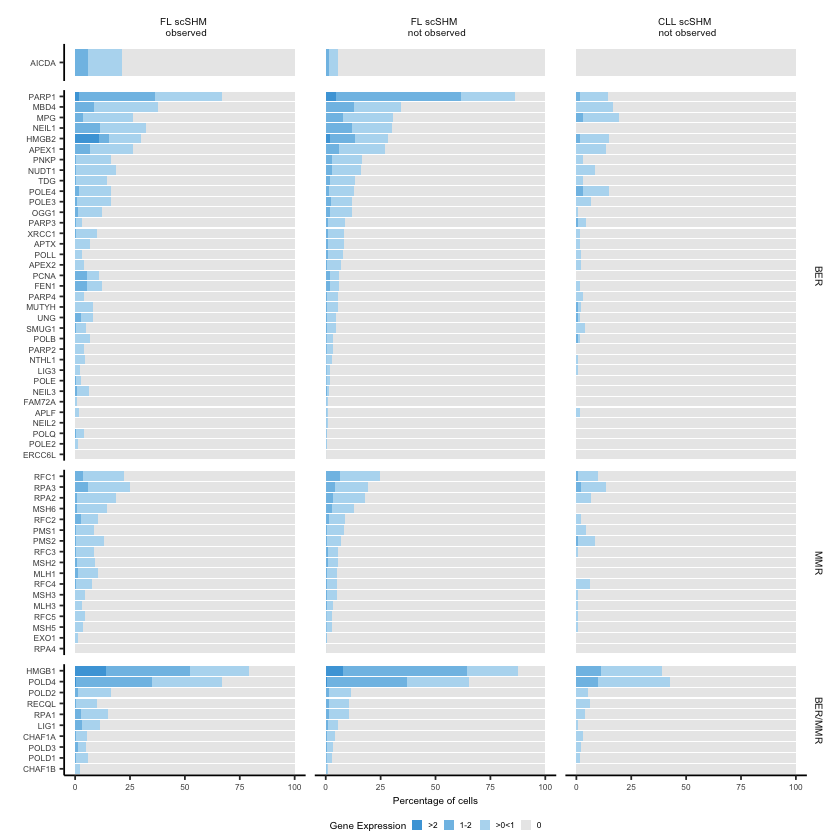

In [84]:
expre_summary <- ggplot(shm_perc_pub_int %>% filter(group != "CLL scSHM \n observed"), aes(x = gene, y = perc, fill = expression_cat)) +
  geom_bar(stat = "identity") +
#  scale_fill_manual(values = c("#d3d3d3","#B4617A","#1c9262","#384abd","#4aa5dc","#a09ece"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +
  scale_fill_manual(values = c("#e9e9e9","#b6dbf1","#80c0e6","#4aa5dc","#384abd","#273384","#384abd","#273384"), name = "Gene Expression", guide = guide_legend(reverse = TRUE)) +

  labs(x = "", y = "Percentage of cells") +
  theme_classic() +
#  scale_x_discrete(labels = c("neg_shm" = "SHMa not observed", "pos_shm" = "SHMa observed")) +
  theme(
    legend.position = "bottom", legend.margin = margin(t = -0.1, unit = "cm"),
    axis.text = element_text(size = 5, angle = 0),
    axis.title = element_text(size = 6),
    legend.title = element_text(size = 6), legend.text = element_text(size = 5), legend.key.size = unit(0.5, "line"),
    strip.text.x = element_text(size = 6),strip.text.y = element_text(size = 6), strip.background = element_blank()) +
  facet_grid(pathway ~ group, scales = "free", space = "free",labeller = labeller(pathway = pathway.labs )) +  # labeller = labeller(group = group.labs)
  force_panelsizes(rows = c(0.1, 1,0.5,0.3)) +
  coord_flip() #+
#  scale_x_discrete(expand = c(1, 0.5,0,0)) +



fig_save(expre_summary, filename = "figs/DNA_repair_expresion_norm", formats = c("pdf", "png"), width = 7, height = 12, units = "cm", dpi = 320)
expre_summary

In [85]:
fig_save(expre_summary, filename = "figs/DNA_repair_expresion_norm_K45678", formats = c("pdf", "png"), width = 20, height = 12, units = "cm", dpi = 320)
#expre_summary